In [ ]:
# The Scenario: You are tasked with building a basic version of Photoshop 
#             using only mathematical operations.
# Creating Arrays & Attributes: You load a provided image (using a library 
#             like matplotlib.image to read it into a NumPy array). You must 
#             inspect .shape, .ndim, and .dtype to understand how the pixels 
#             and RGB channels are structured, and create a blank "canvas" 
#             using np.zeros().
# Indexing, Slicing & Masking: 
# Slicing: Crop the image to focus on a specific subject (e.g., img[100:500, 
#             200:600]).
# Indexing: Isolate only the Red channel of the image.
# Masking: Create a "green screen" effect. Find all pixels where the green 
#             value is high and replace them with pixels from a completely
#             different background array.
# Vectorization, Broadcasting & Ufuncs: Increase the image's brightness by 
#             simply adding a scalar value (e.g., img + 50 demonstrating 
#             broadcasting). Apply a gamma correction or vintage filter using
#             np.power() and np.sqrt() (ufuncs) without writing a single for 
#             loop.
# Math & Stats: Find the brightest and darkest pixels in the image (np.max, 
#             np.min). Calculate the average pixel intensity of the image to 
#             determine if it is "overexposed" or “underexposed” 
#             (np.mean across specific axes).

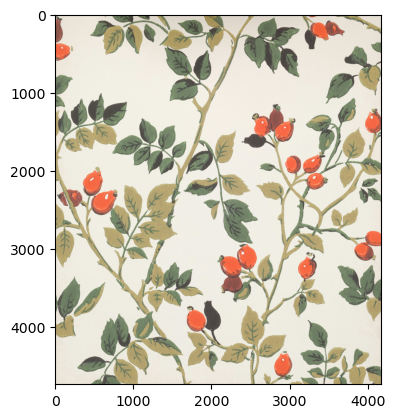

(4733, 4171, 3)
3
uint8
[[[229 221 210]
  [222 214 203]
  [230 222 211]
  ...
  [225 219 207]
  [225 219 207]
  [226 220 208]]

 [[223 215 204]
  [220 212 201]
  [226 218 207]
  ...
  [221 215 203]
  [221 215 203]
  [223 217 205]]

 [[230 222 211]
  [230 222 211]
  [230 222 211]
  ...
  [220 214 202]
  [219 213 201]
  [219 213 201]]

 ...

 [[229 223 211]
  [222 216 204]
  [223 217 205]
  ...
  [195 182 130]
  [176 160 108]
  [169 154  99]]

 [[222 216 204]
  [226 220 208]
  [229 223 211]
  ...
  [177 163 114]
  [168 152 101]
  [170 154 102]]

 [[232 224 213]
  [226 218 207]
  [228 220 209]
  ...
  [158 144  97]
  [156 142  93]
  [169 153 104]]]
[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.

In [15]:
import matplotlib.image as mpimg 
import matplotlib.pyplot as plt
import numpy as np

img_array = mpimg.imread("photo1.jpg")  

plt.imshow(img_array)
plt.show()

print(img_array.shape)
print(img_array.ndim)
print(img_array.dtype)
print(img_array)

blank_canvas = np.zeros(img_array.shape)
print(blank_canvas)

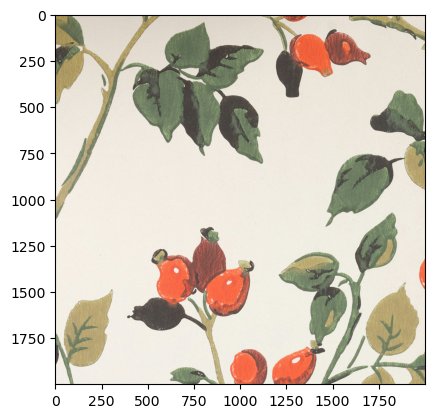

In [4]:
# SLICING
crop = img_array[0:2000, 2000:4000]
plt.imshow(crop)
plt.show()

(4733, 4171)


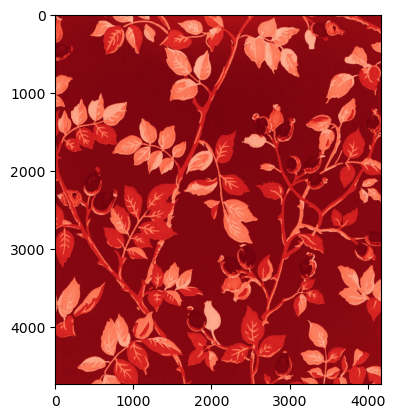

In [14]:
# INDEXING
red_channel = img_array[:, :, 0]
print(red_channel.shape)
plt.imshow(red_channel, cmap='Reds')
plt.show()

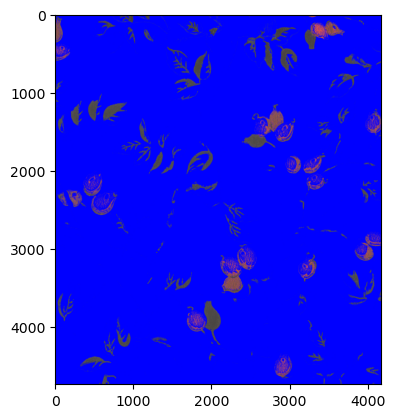

In [6]:
# MASKING
background = np.zeros(img_array.shape)
background[:, :, 2] = 255

green_channel = img_array[:, :, 1]
mask = green_channel > 100 

green_screen = img_array.copy()
green_screen[mask] = background[mask]
plt.imshow(green_screen)
plt.show()

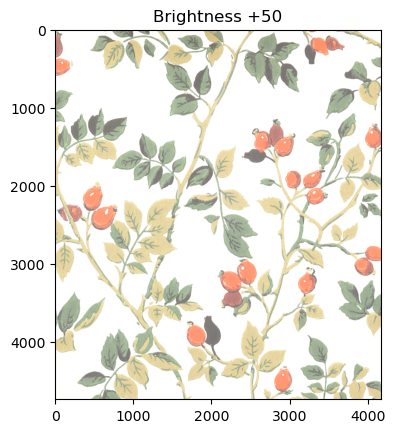

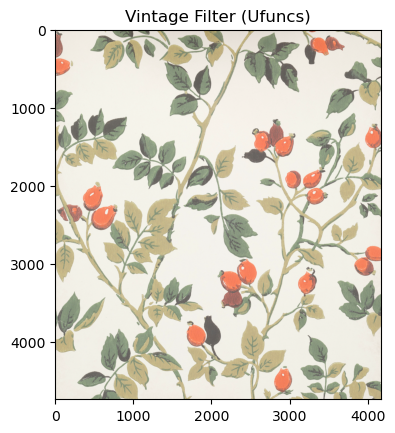

In [7]:
# Vectorization, Broadcasting & Ufuncs
# --- BRIGHTNESS (Broadcasting) ---
bright_img = np.clip(img_array.astype(np.int16) + 50, 0, 255).astype(np.uint8)

plt.title("Brightness +50")
plt.imshow(bright_img)
plt.show()

# --- VINTAGE/GAMMA FILTER (Ufuncs) ---
normalized_img = img_array / 255.0

gamma_img = np.power(normalized_img, 1.5) 

vintage_img = np.sqrt(gamma_img)

filter_img = (vintage_img * 255).astype(np.uint8)

plt.title("Vintage Filter (Ufuncs)")
plt.imshow(filter_img)
plt.show()

In [16]:
# MATH & STATS
darkest = np.min(img_array)
brightest = np.max(img_array)
print(f"Darkest pixel value: {darkest}")
print(f"Brightest pixel value: {brightest}")

average_intensity = np.mean(img_array)
print(f"Average Intensity: {average_intensity:.2f}")

if average_intensity > 180:
    print("The image is Overexposed")
elif average_intensity < 70:
    print("The image is Underexposed")
else:
    print("The image is Well-exposed")

# Average for [Red, Green, Blue] separately
channel_means = np.mean(img_array, axis=(0, 1))

print(f"Average Red: {channel_means[0]:.2f}")
print(f"Average Green: {channel_means[1]:.2f}")
print(f"Average Blue: {channel_means[2]:.2f}")

Darkest pixel value: 0
Brightest pixel value: 255
Average Intensity: 192.94
The image is Overexposed
Average Red: 204.54
Average Green: 196.99
Average Blue: 177.28
